## 1. Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from module_function import (cross_validate_model,evalute_models_classification,feature_importance,plot_residuals,
                             Hyperparameter_Tuning,plot_tuned_feature_importance,plot_confusion_matrix,plot_roc_curves)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('dataset/heart_failure_clinical_records_CLEANING.csv')
df_x = df.drop(columns='DEATH_EVENT')
df_y = df['DEATH_EVENT']

In [3]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,stratify=df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 145 samples
Test set: 37 samples


## 2.Feature Scaling

In [4]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

## 3.Pipeline All Models Classification

In [5]:
classification_pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=8)),
        ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    
    'Random Forest Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=8)),
        ('model', RandomForestClassifier(random_state=42, n_estimators=100))
    ]),
    
    'Gradient Boosting Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=8)),
        ('model', GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1))
    ]),
    
    'XGBoost Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=8)),
        ('model', XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.1, eval_metric='logloss'))
    ]),
    
    'Support Vector Classifier (SVC)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=8)),
        ('model', SVC(random_state=42, probability=True, kernel='rbf')) # probability=True berguna jika butuh nilai AUC-ROC
    ]),
    
    'AdaBoost Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=8)),
        ('model', AdaBoostClassifier(random_state=42, n_estimators=100, learning_rate=0.1))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [6]:
predictions_dict = {}
for model_name, pipeline in classification_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evalute_models_classification( model_dict=predictions_dict, y_test=y_test,averages='macro')
df_report.sort_values(by='Accuracy', ascending=False)

Menguji model: Logistic Regression
=== CLASSIFICATION REPORT: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.75      0.84        28
           1       0.53      0.89      0.67         9

    accuracy                           0.78        37
   macro avg       0.74      0.82      0.75        37
weighted avg       0.85      0.78      0.80        37



Menguji model: Random Forest Classifier
=== CLASSIFICATION REPORT: Random Forest Classifier ===
              precision    recall  f1-score   support

           0       0.95      0.75      0.84        28
           1       0.53      0.89      0.67         9

    accuracy                           0.78        37
   macro avg       0.74      0.82      0.75        37
weighted avg       0.85      0.78      0.80        37



Menguji model: Gradient Boosting Classifier
=== CLASSIFICATION REPORT: Gradient Boosting Classifier ===
              precision    recall  f1-score   support

 

,Model,Accuracy,Precision,Recall,F1-Score
3,XGBoost Classifier,0.810811,0.781250,0.875000,0.788571
2,Gradient Boosting Classifier,0.810811,0.763975,0.837302,0.779199
1,Random Forest Classifier,0.783784,0.743939,0.819444,0.753333
0,Logistic Regression,0.783784,0.743939,0.819444,0.753333
5,AdaBoost Classifier,0.783784,0.743939,0.819444,0.753333
4,Support Vector Classifier (SVC),0.729730,0.710294,0.783730,0.703526


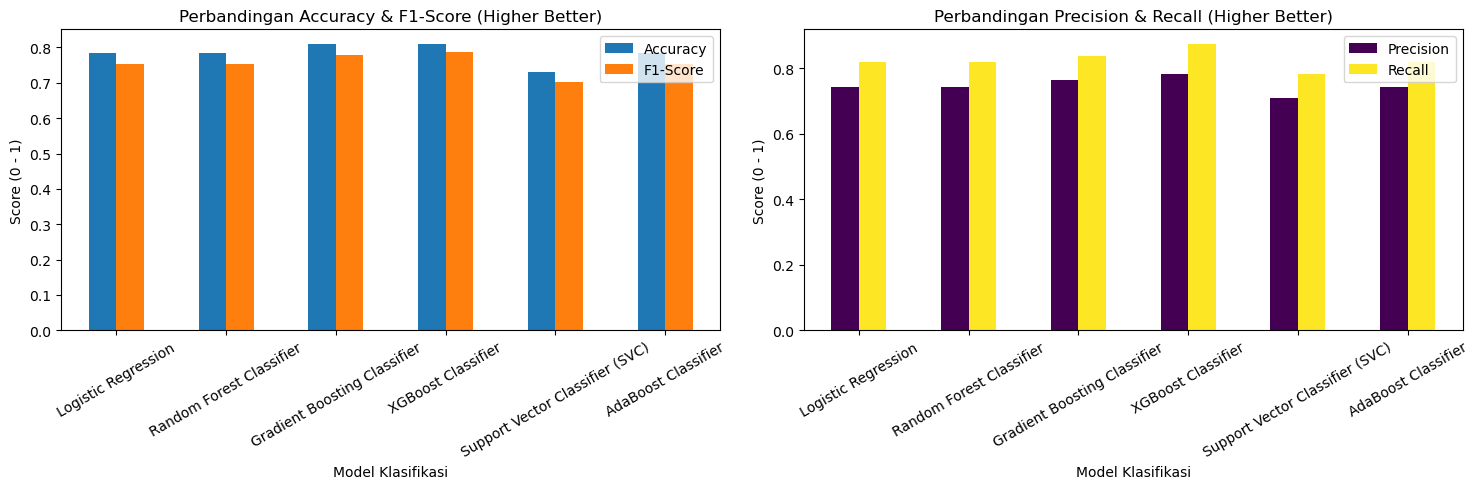

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Perbandingan Accuracy & F1-Score (Higher Better)', fontsize=12)
axes[0].set_ylabel('Score (0 - 1)')
axes[0].set_xlabel('Model Klasifikasi')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['Precision', 'Recall']].plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Perbandingan Precision & Recall (Higher Better)', fontsize=12)
axes[1].set_ylabel('Score (0 - 1)')
axes[1].set_xlabel('Model Klasifikasi')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

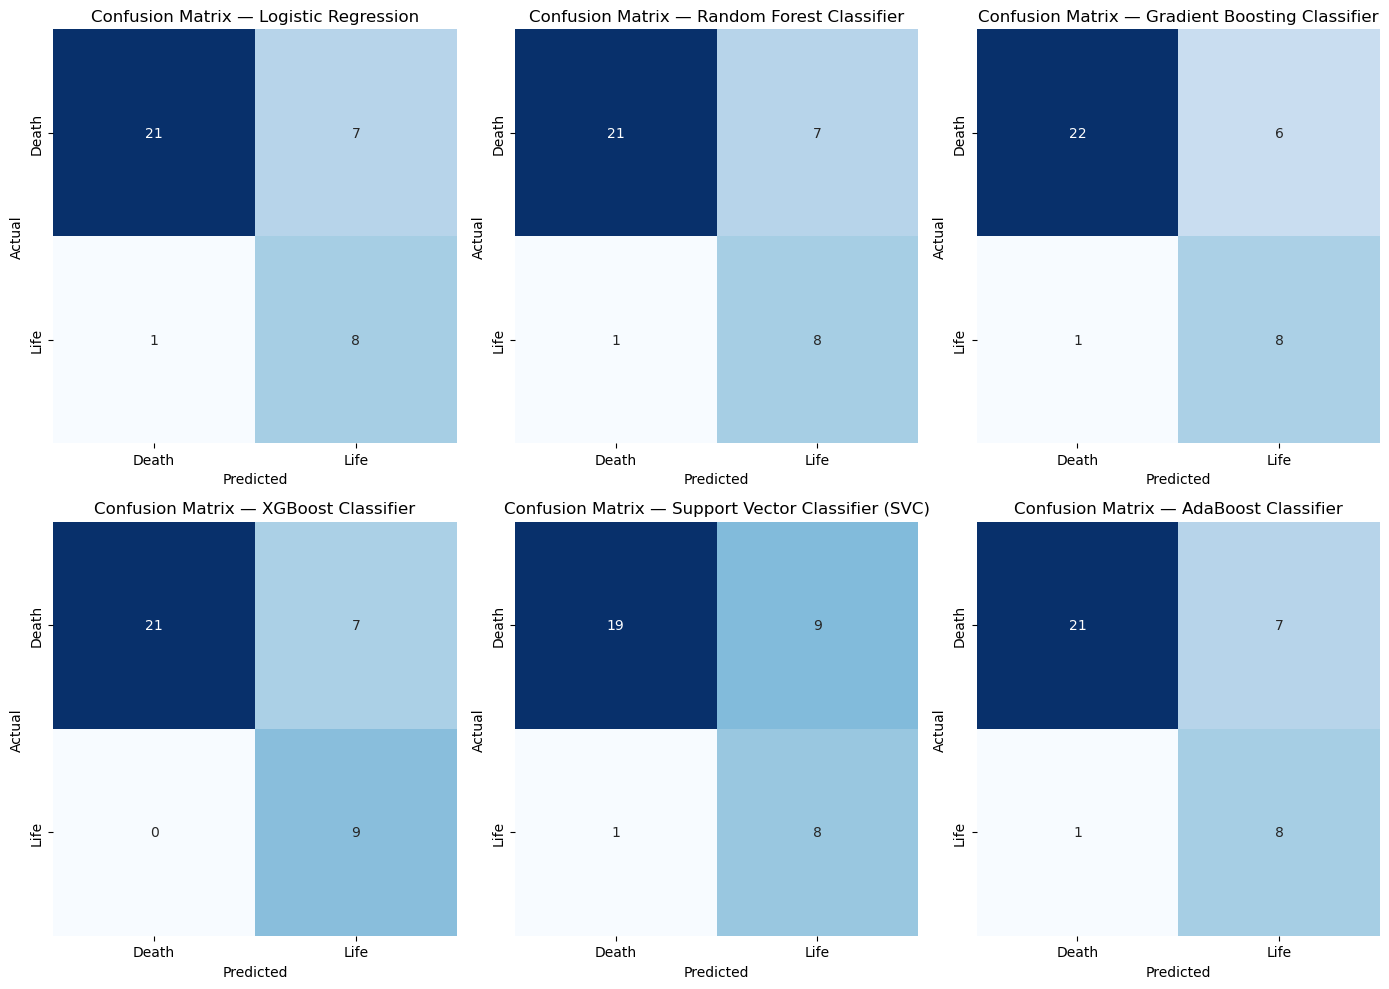

In [8]:
label = ['Death', 'Life']
plot_confusion_matrix(model_dict=predictions_dict,y_test=y_test,labels=label)

## 5.Analysis Model Sesudah Cross-Validate

In [9]:
df_hasil_perbandingan = cross_validate_model(models_dict=classification_pipelines, X=X_train, y=y_train, cv_folds=5, mode='classification')
df_hasil_perbandingan.sort_values(by='Accuracy', ascending=False)

=== MENJALANKAN STRATIFIED 5-FOLD CROSS VALIDATION (KLASIFIKASI) ===

Menguji model: Logistic Regression
Menguji model: Random Forest Classifier
Menguji model: Gradient Boosting Classifier
Menguji model: XGBoost Classifier
Menguji model: Support Vector Classifier (SVC)
Menguji model: AdaBoost Classifier

Proses CV Selesai!


,Model,Accuracy,Precision,Recall,F1-Score
3,XGBoost Classifier,0.793103,0.762580,0.814935,0.758637
5,AdaBoost Classifier,0.786207,0.748049,0.790909,0.747262
0,Logistic Regression,0.765517,0.733630,0.777273,0.729785
1,Random Forest Classifier,0.751724,0.713668,0.758442,0.710023
4,Support Vector Classifier (SVC),0.744828,0.716155,0.763636,0.709284
2,Gradient Boosting Classifier,0.731034,0.687687,0.705844,0.675106


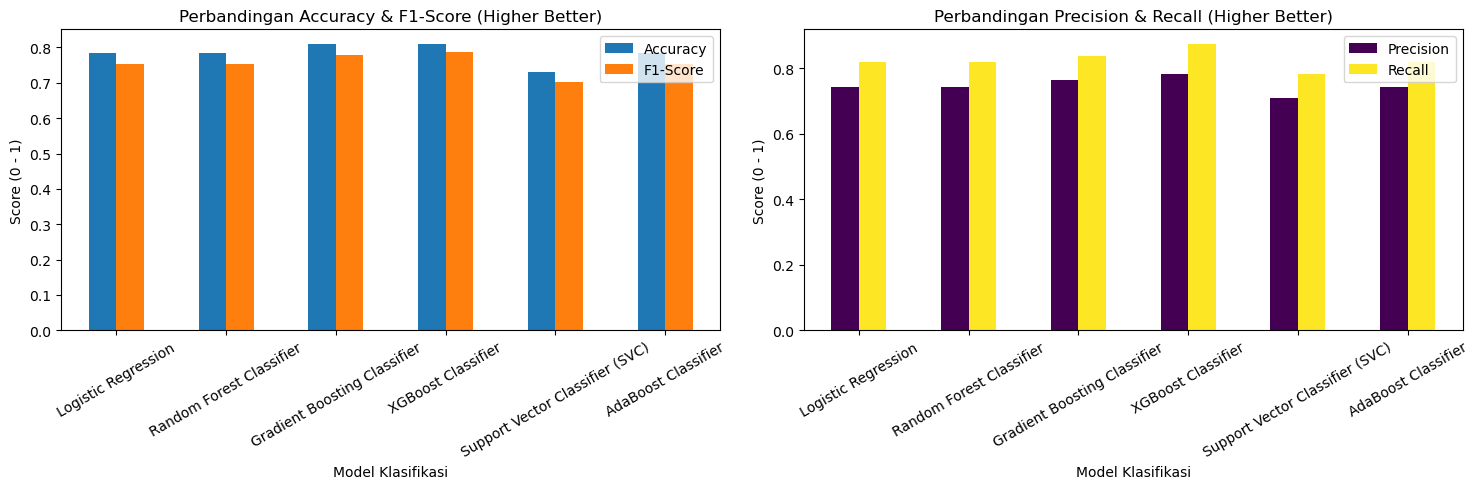

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Perbandingan Accuracy & F1-Score (Higher Better)', fontsize=12)
axes[0].set_ylabel('Score (0 - 1)')
axes[0].set_xlabel('Model Klasifikasi')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['Precision', 'Recall']].plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Perbandingan Precision & Recall (Higher Better)', fontsize=12)
axes[1].set_ylabel('Score (0 - 1)')
axes[1].set_xlabel('Model Klasifikasi')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Analysis Nilai Asli dan Nilai Prediksi